# Задание: Распознавание рукописных цифр (MNIST) — fine-tuning ResNet50 на PyTorch

Вместо обучения свёрточной сети с нуля используется **fine-tuning** предобученной модели **ResNet50** из библиотеки `torchvision.models`.

**Структура модели:**
- предобученная база ResNet50 (49 свёрточных слоёв, BatchNormalization, MaxPooling — внутри неё)
- заменённая «голова»: AdaptiveAvgPool → Flatten → BatchNorm → Linear(2048→128) → Dropout → Linear(128→10)

**Гиперпараметры:** кроссэнтропия, Adam (lr = 1e-3 → 1e-5), batch = 128, всего 15 эпох (5 + 10).

**Стратегия fine-tuning (двухэтапная):**
1. *Этап 1.* Вся база заморожена, обучается только новая голова (5 эпох, lr = 1e-3).
2. *Этап 2.* Размораживается последний residual-блок (`layer4`), донастройка с lr = 1e-5 (10 эпох).


## Загрузка библиотек

In [1]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Базовые библиотеки
import numpy as np
import matplotlib.pyplot as plt
import random

# Метрики
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Вывод изображений в ноутбуке
%matplotlib inline

# Определение устройства (GPU если доступен)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используется устройство: {device}')


Используется устройство: cuda


## Загрузка датасета MNIST

In [2]:
# Преобразования под ResNet50:
# 1. Ресайз 28x28 -> 64x64 (ResNet50 ждёт минимум 32x32; 64 — разумный компромисс).
# 2. Grayscale -> RGB (повтор единственного канала 3 раза).
# 3. ToTensor: [0..255] -> [0..1], порядок каналов HWC -> CHW.
# 4. Нормализация под ImageNet (те же mean/std, на которых училась ResNet50).
IMG_SIZE = 64

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),             # 28x28 -> 64x64
    transforms.Grayscale(num_output_channels=3),         # 1 канал -> 3 канала (RGB)
    transforms.ToTensor(),                               # -> [0, 1], CHW
    transforms.Normalize(                                # нормализация под ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Загрузка обучающей и проверочной выборок
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f'Размер обучающей выборки: {len(train_dataset)}')
print(f'Размер тестовой выборки:  {len(test_dataset)}')
print(f'Форма одного изображения: {train_dataset[0][0].shape}')  # ожидаем (3, 64, 64)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.7MB/s]

Размер обучающей выборки: 60000
Размер тестовой выборки:  10000
Форма одного изображения: torch.Size([3, 64, 64])


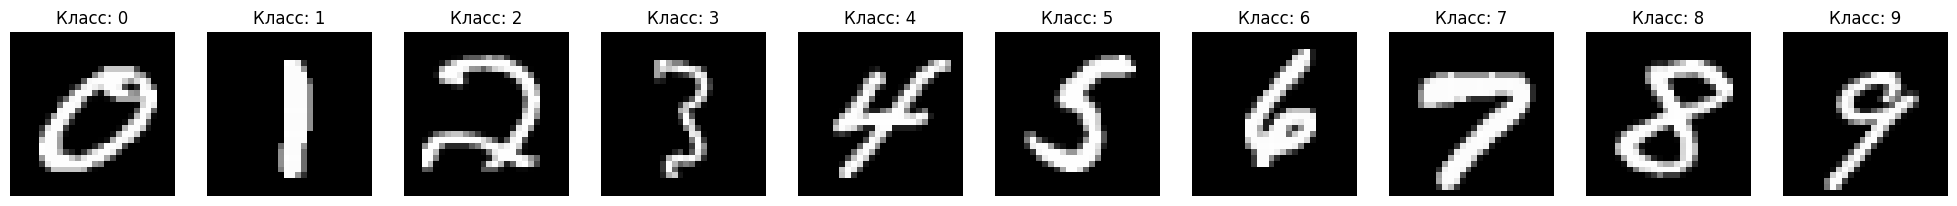

In [3]:
# Просмотр изображений каждого класса для ознакомления с датасетом.
# Берём из train_dataset.data — это исходные 28x28 ЧБ картинки (до transform).
fig, axs = plt.subplots(1, 10, figsize=(25, 3))

all_labels = train_dataset.targets.numpy()
all_images = train_dataset.data.numpy()

for i in range(10):
    label_indexes = np.where(all_labels == i)[0]
    index = random.choice(label_indexes)
    img = all_images[index]
    axs[i].imshow(img, cmap='gray')
    axs[i].set_title(f'Класс: {i}')
    axs[i].axis('off')

plt.show()


In [4]:
# Создание DataLoader-ов с размером батча 128
BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Проверка размерностей
for images, labels in train_loader:
    print(f'Форма батча изображений: {images.shape}')   # ожидаем [128, 3, 64, 64]
    print(f'Форма батча меток:       {labels.shape}')   # [128]
    break


Форма батча изображений: torch.Size([128, 3, 64, 64])
Форма батча меток:       torch.Size([128])


## Создание модели: fine-tuning ResNet50

В отличие от Keras, в PyTorch нет `include_top=False`. Мы загружаем полную ResNet50 и **вручную заменяем её последний слой** `model.fc` на свою голову под 10 классов.

На первом этапе все параметры базы замораживаются (`requires_grad = False`), кроме новой головы — именно она будет обучаться. На втором этапе разморозим `layer4` (последний из четырёх residual-блоков ResNet50) и продолжим обучение с очень маленьким `lr`.


In [5]:
# Загружаем предобученную ResNet50 (на ImageNet)
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

#  ЭТАП 1: замораживаем ВСЁ
for param in resnet.parameters():
    param.requires_grad = False

#  Заменяем последний слой (голову) на свой
# Оригинал: resnet.fc = nn.Linear(2048, 1000)  (1000 классов ImageNet)
# Свой блок: BatchNorm -> Linear(2048->128) -> ReLU -> Dropout -> Linear(128->10)
# Параметры новой головы по умолчанию имеют requires_grad=True — то, что нам нужно.
num_features = resnet.fc.in_features  # 2048
resnet.fc = nn.Sequential(
    nn.BatchNorm1d(num_features),
    nn.Linear(num_features, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(128, 10),
)

model = resnet.to(device)

# Подсчёт параметров — на 1-м этапе обучаемых должно быть в десятки раз меньше общего числа
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Всего параметров:     {total_params:,}')
print(f'Обучаемых (этап 1):   {trainable_params:,}')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]


Всего параметров:     23,775,690
Обучаемых (этап 1):   267,658


## Обучение модели (двухэтапное)

Чтобы избежать дублирования кода цикла обучения для двух этапов, оборачиваем его в функцию `train_model()`.


In [6]:
#  Функция обучения (один проход)
criterion = nn.CrossEntropyLoss()

def train_model(model, optimizer, n_epochs, history, epoch_offset=0):
    '''Обучает модель n_epochs эпох, дописывая метрики в history.'''
    for epoch in range(n_epochs):
        #  Фаза обучения
        model.train()
        train_loss_sum = 0.0
        train_correct  = 0
        train_total    = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_total   += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        #  Фаза валидации
        model.eval()
        val_loss_sum = 0.0
        val_correct  = 0
        val_total    = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss_sum += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total   += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total

        history['train_loss'].append(train_loss)
        history['train_acc' ].append(train_acc)
        history['val_loss'  ].append(val_loss)
        history['val_acc'   ].append(val_acc)

        global_epoch = epoch + 1 + epoch_offset
        print(f'Эпоха {global_epoch:2d} | '
              f'train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | '
              f'val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}')


# Общая история на оба этапа
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 10

#  ЭТАП 1: обучаем только голову, lr = 1e-3
# В optimizer передаём только параметры с requires_grad=True (т.е. новую голову).
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

print('ЭТАП 1: обучение головы (база ResNet50 заморожена)')
train_model(model, optimizer, EPOCHS_STAGE1, history, epoch_offset=0)

#  ЭТАП 2: размораживаем layer4 (последний residual-блок ResNet50), lr = 1e-5
# Размораживать всю ResNet50 для маленького датасета как MNIST рискованно — переобучимся.
# Поэтому размораживаем только верхушку.
for param in model.layer4.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nОбучаемых параметров после разморозки layer4: {trainable_params:,}')

# Очень маленький lr, чтобы не «сломать» предобученные веса
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

print()
print('ЭТАП 2: fine-tuning layer4 (lr = 1e-5)')
train_model(model, optimizer, EPOCHS_STAGE2, history, epoch_offset=EPOCHS_STAGE1)

print('\nОбучение завершено!')


ЭТАП 1: обучение головы (база ResNet50 заморожена)
Эпоха  1 | train_loss: 0.6818 | train_acc: 0.7795 | val_loss: 0.4932 | val_acc: 0.8355
Эпоха  2 | train_loss: 0.4950 | train_acc: 0.8369 | val_loss: 0.4441 | val_acc: 0.8531
Эпоха  3 | train_loss: 0.4630 | train_acc: 0.8458 | val_loss: 0.4543 | val_acc: 0.8515
Эпоха  4 | train_loss: 0.4365 | train_acc: 0.8535 | val_loss: 0.4214 | val_acc: 0.8613
Эпоха  5 | train_loss: 0.4200 | train_acc: 0.8598 | val_loss: 0.4057 | val_acc: 0.8654

Обучаемых параметров после разморозки layer4: 15,232,394

ЭТАП 2: fine-tuning layer4 (lr = 1e-5)
Эпоха  6 | train_loss: 0.3053 | train_acc: 0.8979 | val_loss: 0.3094 | val_acc: 0.9054
Эпоха  7 | train_loss: 0.2193 | train_acc: 0.9274 | val_loss: 0.2377 | val_acc: 0.9243
Эпоха  8 | train_loss: 0.1798 | train_acc: 0.9391 | val_loss: 0.2191 | val_acc: 0.9348
Эпоха  9 | train_loss: 0.1481 | train_acc: 0.9502 | val_loss: 0.2168 | val_acc: 0.9376
Эпоха 10 | train_loss: 0.1276 | train_acc: 0.9576 | val_loss: 0.1851

## График обучения
Доли верных ответов на обучающей и проверочной выборках

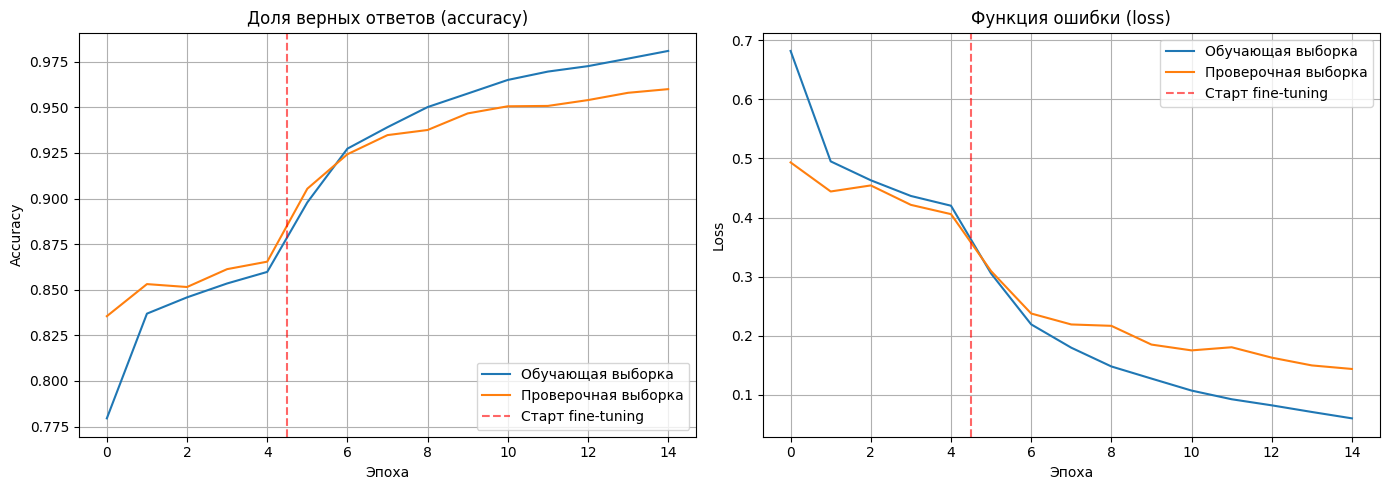

Лучшая точность на проверочной выборке: 96.00%
Итоговая точность на проверочной выборке: 96.00%


In [7]:
plt.figure(figsize=(14, 5))

# Граница между этапом 1 и этапом 2 (для красной пунктирной линии)
stage_boundary = EPOCHS_STAGE1 - 0.5

# График accuracy
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Обучающая выборка')
plt.plot(history['val_acc'],   label='Проверочная выборка')
plt.axvline(x=stage_boundary, color='red', linestyle='--', alpha=0.6, label='Старт fine-tuning')
plt.title('Доля верных ответов (accuracy)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# График loss
plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Обучающая выборка')
plt.plot(history['val_loss'],   label='Проверочная выборка')
plt.axvline(x=stage_boundary, color='red', linestyle='--', alpha=0.6, label='Старт fine-tuning')
plt.title('Функция ошибки (loss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f'Лучшая точность на проверочной выборке: {max(history["val_acc"])*100:.2f}%')
print(f'Итоговая точность на проверочной выборке: {history["val_acc"][-1]*100:.2f}%')


## Матрица ошибок (Confusion Matrix)

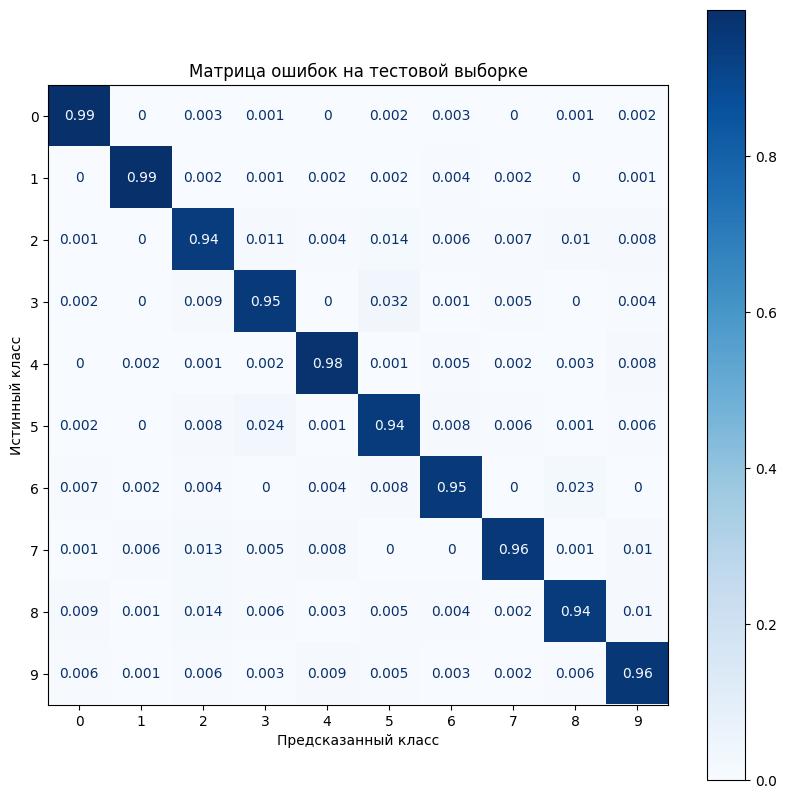


Общая точность на тестовой выборке: 0.9600 (96.00%)


In [8]:
# Получение всех предсказаний на тестовой выборке
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Построение нормализованной матрицы ошибок
cm = confusion_matrix(all_labels, all_preds, normalize='true')
cm = np.round(cm, 3)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title('Матрица ошибок на тестовой выборке')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

# Общая точность
accuracy = (all_preds == all_labels).mean()
print(f'\nОбщая точность на тестовой выборке: {accuracy:.4f} ({accuracy*100:.2f}%)')